In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

In [2]:
df = pd.read_csv("Dataset_Study4.csv")

In [3]:
df.head()

,HRV_MeanNN,HRV_SDNN,HRV_RMSSD,HRV_Prc20NN,HRV_Prc80NN,HRV_pNN50,HRV_HTI,HRV_VLF,HRV_LF,HRV_HF,HRV_TP,HRV_LFHF,HRV_SD1,HRV_SD2,HRV_SD1SD2,HRV_DFA_alpha1,HRV_DFA_alpha2,HRV_ApEn,HRV_SampEn,Label
0,833.314763,106.424590,88.217436,733.8,932.0,50.277778,24.000000,62.654127,713.021695,4228.126423,5161.003600,0.168638,62.465836,137.040902,0.455819,0.739535,0.976855,1.207556,1.658034,-1
1,766.966581,92.330308,76.581684,682.8,856.0,49.487179,18.571429,73.007851,1245.114713,3010.533164,4423.639565,0.413586,54.220273,118.651968,0.456969,0.808348,0.848391,1.216319,1.658744,210
2,896.408408,61.685886,51.577499,851.2,948.0,36.526946,14.521739,36.950885,1201.268110,1179.137264,2458.917474,1.018769,36.525411,79.282979,0.460697,1.004529,0.580331,1.156607,1.716762,-1
3,833.256267,71.637093,46.592095,789.8,889.0,26.666667,12.857143,156.099084,1241.711995,1299.760891,2731.734549,0.955339,32.991403,95.896771,0.344030,1.087338,0.917225,1.193158,1.469750,110
4,782.793194,45.483921,21.992054,753.4,820.0,1.566580,9.820513,28.439521,396.440159,156.126782,591.933499,2.539219,15.571013,62.476536,0.249230,1.317823,0.784597,1.072226,1.257610,-1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 166 entries, 0 to 165
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   HRV_MeanNN      166 non-null    float64
 1   HRV_SDNN        166 non-null    float64
 2   HRV_RMSSD       166 non-null    float64
 3   HRV_Prc20NN     166 non-null    float64
 4   HRV_Prc80NN     166 non-null    float64
 5   HRV_pNN50       166 non-null    float64
 6   HRV_HTI         166 non-null    float64
 7   HRV_VLF         166 non-null    float64
 8   HRV_LF          166 non-null    float64
 9   HRV_HF          166 non-null    float64
 10  HRV_TP          166 non-null    float64
 11  HRV_LFHF        166 non-null    float64
 12  HRV_SD1         166 non-null    float64
 13  HRV_SD2         166 non-null    float64
 14  HRV_SD1SD2      166 non-null    float64
 15  HRV_DFA_alpha1  166 non-null    float64
 16  HRV_DFA_alpha2  166 non-null    float64
 17  HRV_ApEn        166 non-null    flo

In [5]:
df.isnull().value_counts()

,,,,,,,,,,,,,,,,,,,,count
HRV_MeanNN,HRV_SDNN,HRV_RMSSD,HRV_Prc20NN,HRV_Prc80NN,HRV_pNN50,HRV_HTI,HRV_VLF,HRV_LF,HRV_HF,HRV_TP,HRV_LFHF,HRV_SD1,HRV_SD2,HRV_SD1SD2,HRV_DFA_alpha1,HRV_DFA_alpha2,HRV_ApEn,HRV_SampEn,Label,
False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,166


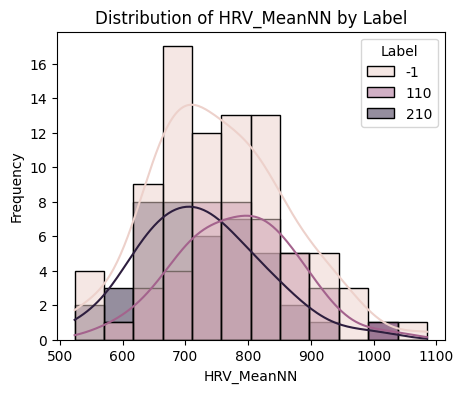

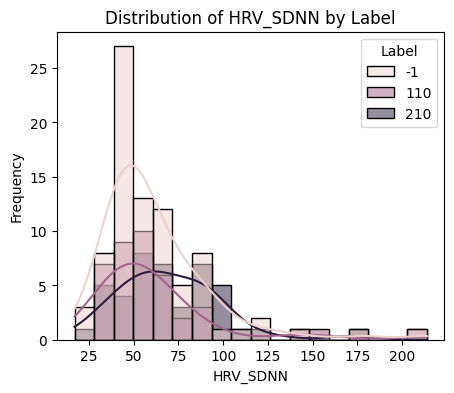

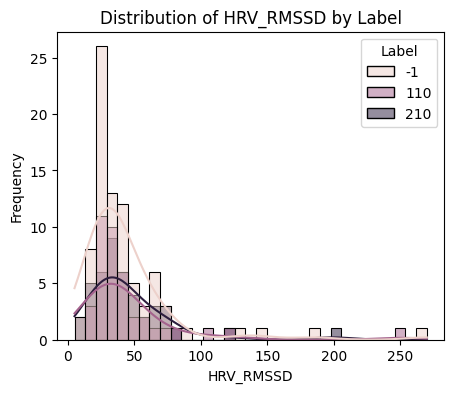

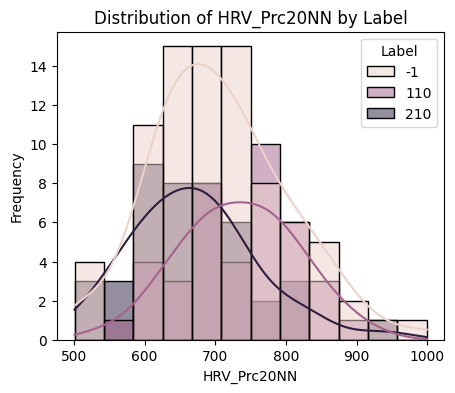

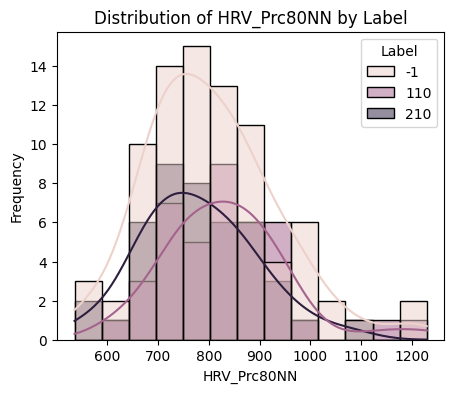

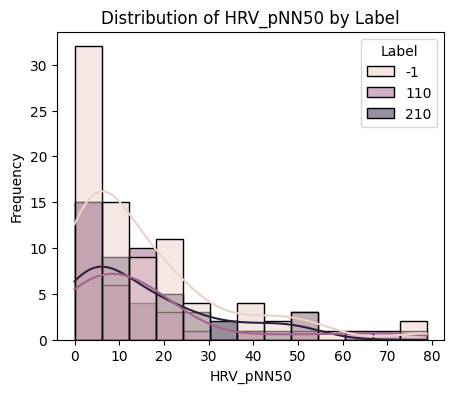

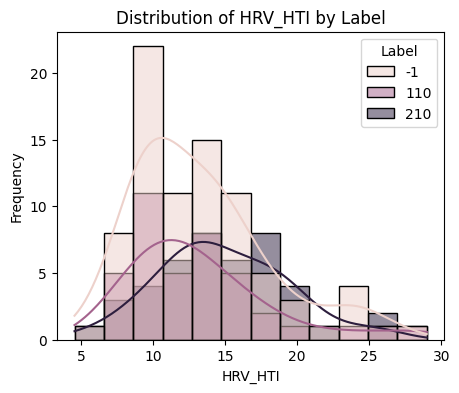

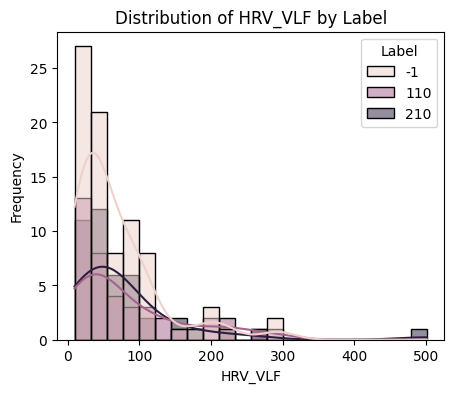

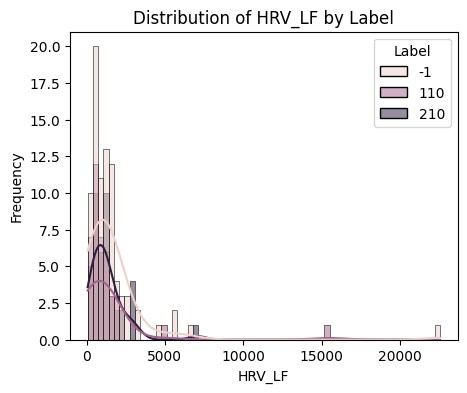

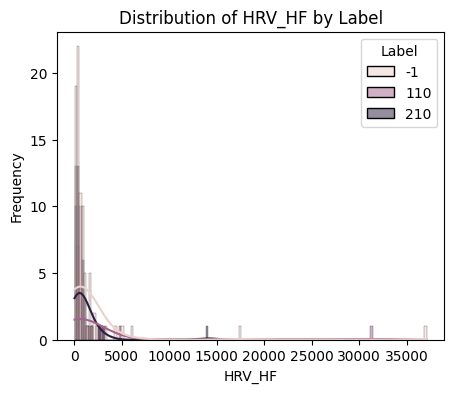

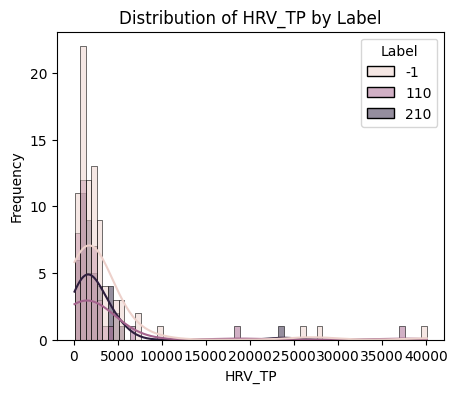

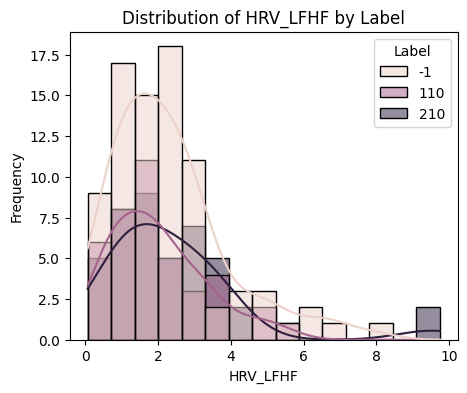

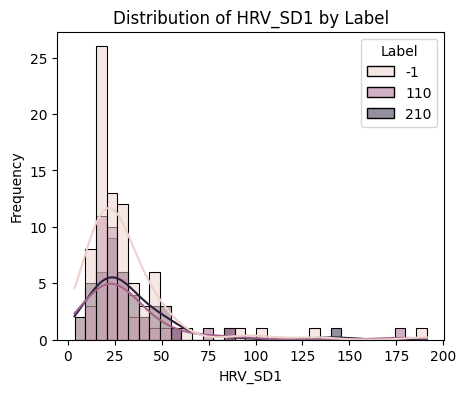

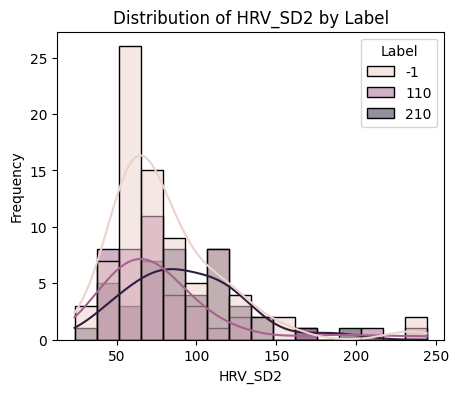

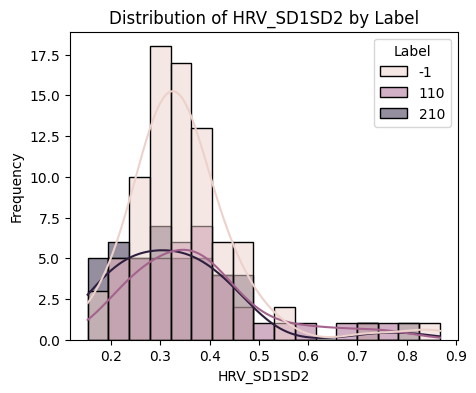

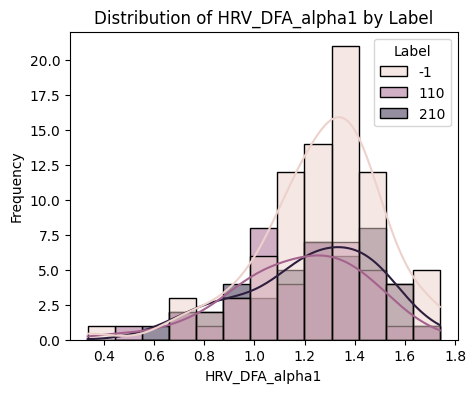

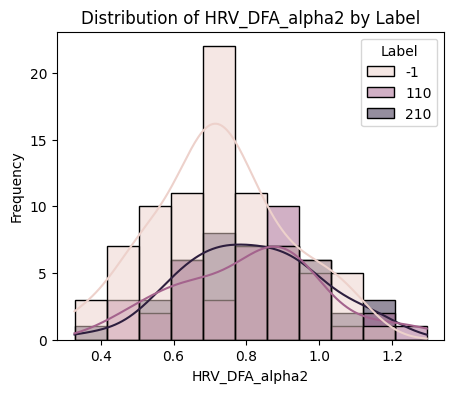

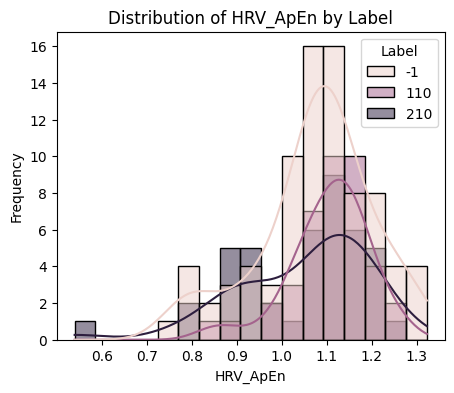

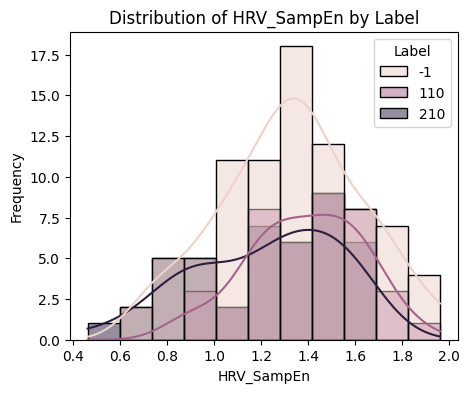

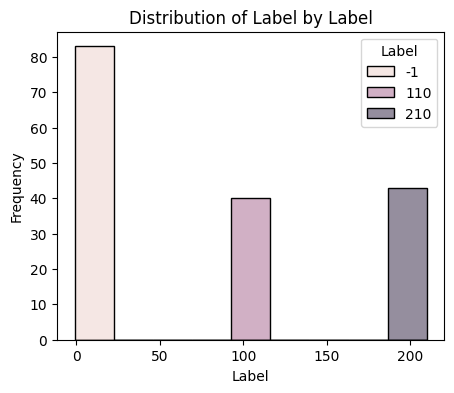

In [6]:
for feature in df.columns:
  plt.figure(figsize=(5, 4))
  sns.histplot(x=feature, hue='Label', data=df, kde=True)
  plt.title(f'Distribution of {feature} by Label')
  plt.xlabel(feature)
  plt.ylabel('Frequency')
  plt.show()

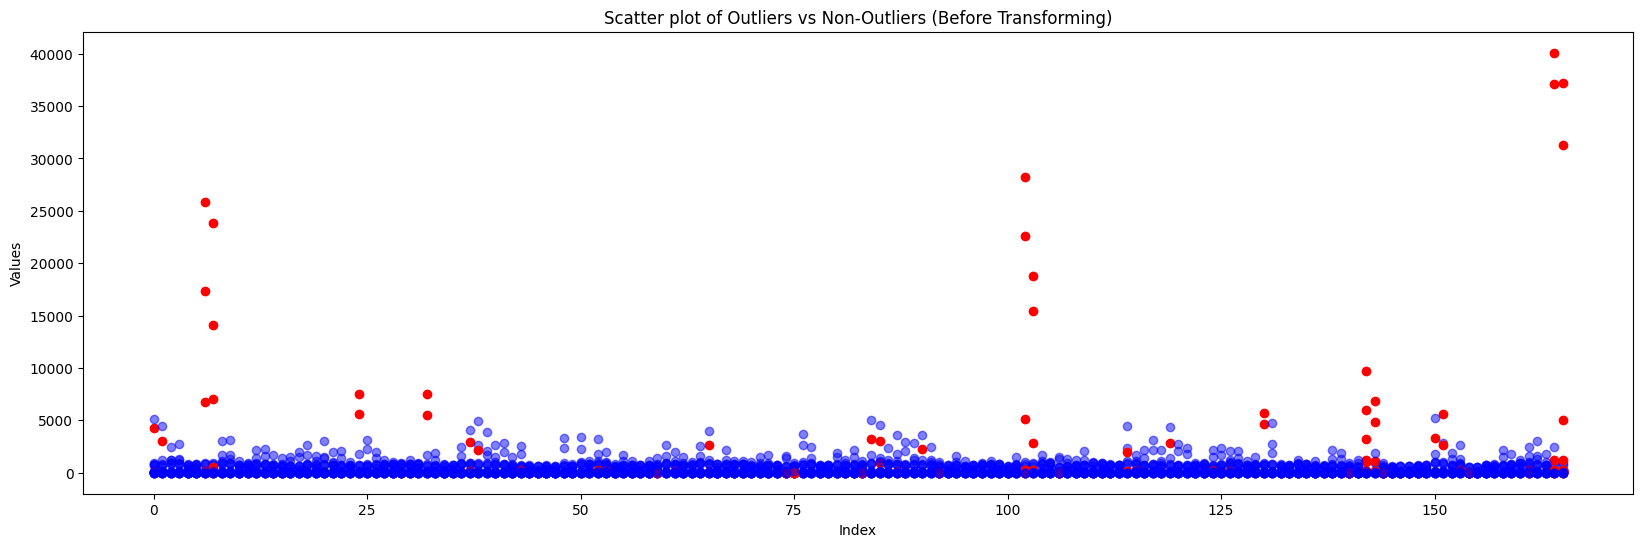

In [7]:
def detect_outliers(features):
    q1 = features.quantile(0.25)
    q3 = features.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = (features < lower_bound) | (features > upper_bound)
    return outliers

plt.figure(figsize=(20, 6))
for column in df.select_dtypes(include='number').columns:
    outliers = detect_outliers(df[column])
    plt.scatter(df.index[outliers], df[column][outliers], color='red')
    plt.scatter(df.index[~outliers], df[column][~outliers], color='blue', alpha=0.5)
plt.title('Scatter plot of Outliers vs Non-Outliers (Before Transforming)')
plt.xlabel('Index')
plt.ylabel('Values')
plt.show()

In [8]:
for column in df.select_dtypes(include='number').columns:
  if column != 'Label':
    outliers = detect_outliers(df[column])
    df.loc[outliers, column] = df[column].median()

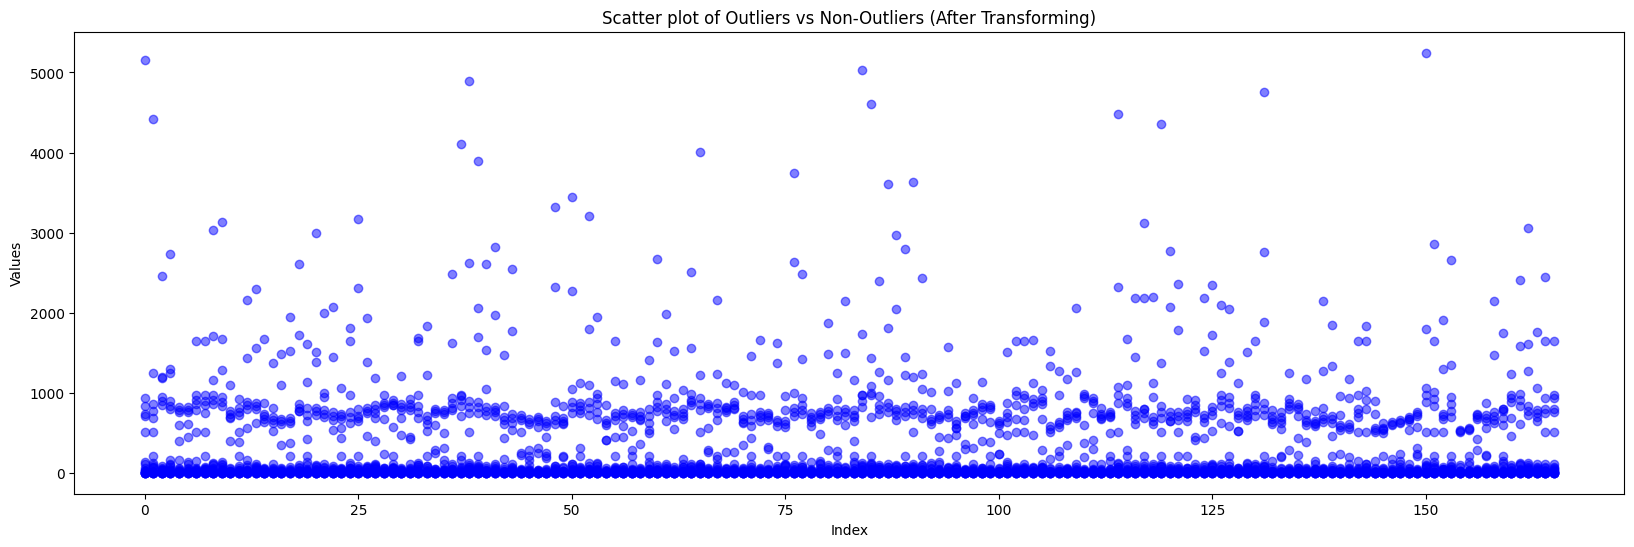

In [9]:
# scatter plot after transforming outliers
plt.figure(figsize=(20, 6))
for column in df.select_dtypes(include='number').columns:
    plt.scatter(df.index, df[column], color='blue', alpha=0.5)
plt.title('Scatter plot of Outliers vs Non-Outliers (After Transforming)')
plt.xlabel('Index')
plt.ylabel('Values')
plt.show()

In [10]:
features = df.drop('Label', axis=1)

In [11]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(features)
X_scaled = pd.DataFrame(X_scaled, columns=features.columns)

In [12]:
X = X_scaled
Y = df['Label']

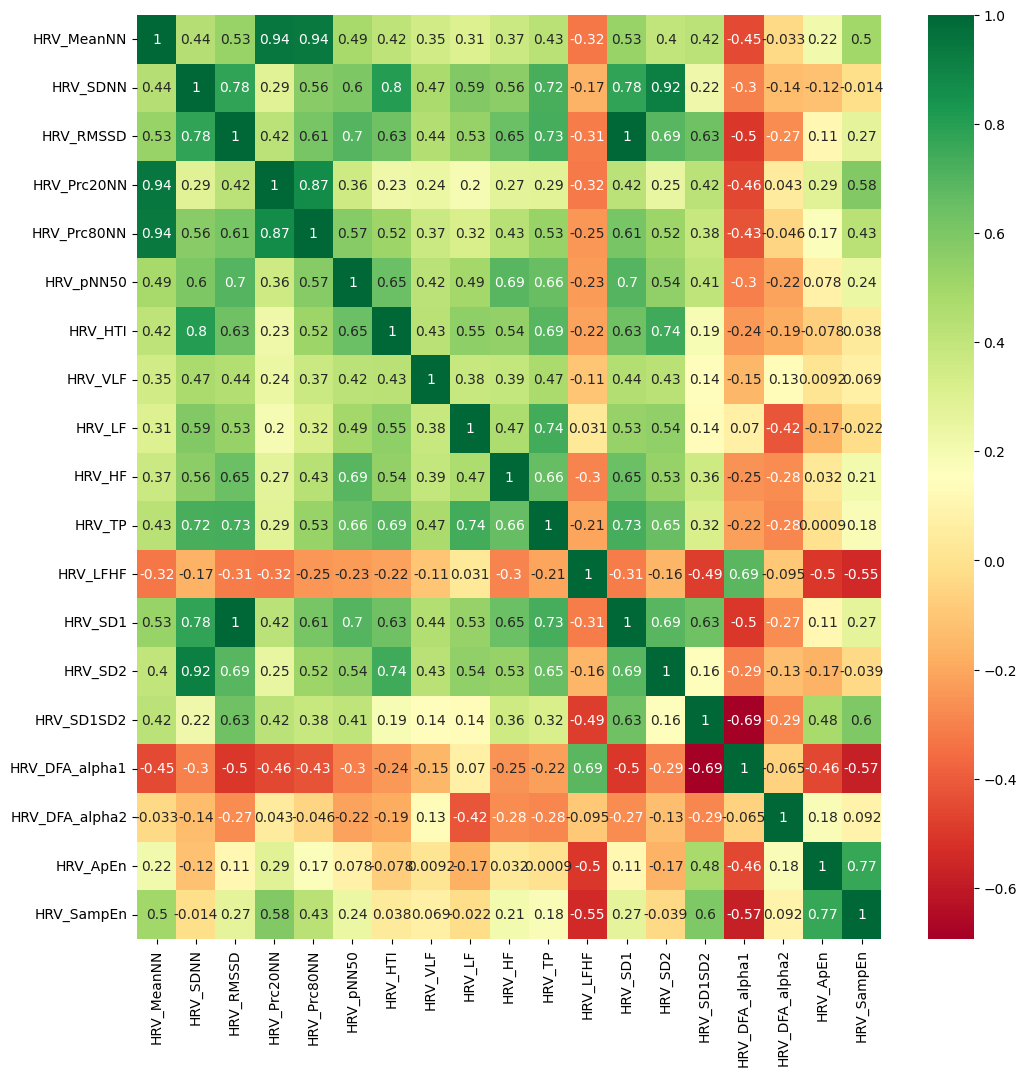

In [13]:
corrmat = X.corr()
plt.figure(figsize=(12,12))
sns.heatmap(corrmat,annot=True,cmap="RdYlGn")
plt.show()

In [14]:
model = LabelEncoder()
y = model.fit_transform(Y)
y

array([0, 2, 0, 1, 0, 1, 0, 2, 0, 1, 0, 2, 0, 1, 0, 1, 0, 2, 0, 2, 0, 1,
       0, 2, 0, 2, 0, 1, 0, 1, 0, 1, 0, 2, 0, 1, 0, 2, 0, 2, 0, 1, 0, 1,
       0, 2, 0, 2, 0, 2, 0, 2, 0, 1, 0, 2, 0, 1, 0, 2, 0, 1, 0, 1, 0, 1,
       0, 2, 0, 1, 0, 2, 0, 1, 0, 2, 0, 2, 0, 1, 0, 2, 0, 2, 0, 2, 0, 1,
       0, 2, 0, 2, 0, 1, 0, 2, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 2, 0, 1,
       0, 1, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 1, 0, 1, 0, 2, 0, 1, 0, 2,
       0, 2, 0, 1, 0, 1, 0, 2, 0, 1, 0, 1, 0, 2, 0, 1, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 0, 1, 0, 1, 0, 1])

ANOVA F-Test Feature Importance Scores:
HRV_Prc20NN       7.051456
HRV_SD2           4.966763
HRV_SDNN          4.862961
HRV_DFA_alpha2    4.148557
HRV_MeanNN        3.596289
HRV_SampEn        2.849382
HRV_HTI           2.409437
HRV_LF            1.858665
HRV_SD1SD2        1.699624
HRV_DFA_alpha1    1.657638
HRV_TP            1.510386
HRV_ApEn          1.424319
HRV_Prc80NN       1.191279
HRV_RMSSD         0.724628
HRV_SD1           0.723607
HRV_pNN50         0.527018
HRV_HF            0.370393
HRV_VLF           0.341345
HRV_LFHF          0.049055
dtype: float64


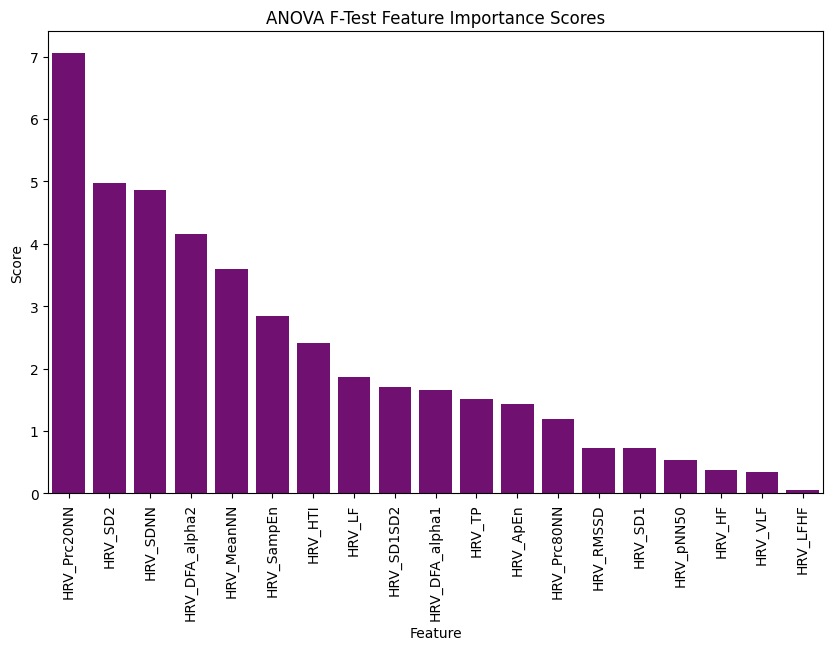

In [15]:
selector = SelectKBest(f_classif, k=10)
X_selected = selector.fit_transform(X, y)
anova_feature_importances = pd.Series(selector.scores_, index=X.columns)

print("ANOVA F-Test Feature Importance Scores:")
print(anova_feature_importances.sort_values(ascending=False))

plt.figure(figsize=(10, 6))
sns.barplot(x=anova_feature_importances.index, y=anova_feature_importances.values, order=anova_feature_importances.sort_values(ascending=False).index, color='purple')
plt.xticks(rotation=90)
plt.title('ANOVA F-Test Feature Importance Scores')
plt.xlabel('Feature')
plt.ylabel('Score')
plt.show()

Logistic Regression Feature Importance Scores:
HRV_DFA_alpha2    0.992971
HRV_DFA_alpha1    0.864762
HRV_ApEn          0.487805
HRV_Prc20NN       0.450947
HRV_HTI           0.391674
HRV_TP            0.367260
HRV_RMSSD         0.266985
HRV_SD1           0.266796
HRV_SD1SD2        0.256417
HRV_SDNN          0.240794
HRV_LFHF          0.190203
HRV_LF            0.156618
HRV_pNN50         0.137754
HRV_MeanNN        0.119532
HRV_SD2           0.117421
HRV_VLF           0.116554
HRV_HF            0.101662
HRV_Prc80NN       0.037403
HRV_SampEn        0.003974
dtype: float64


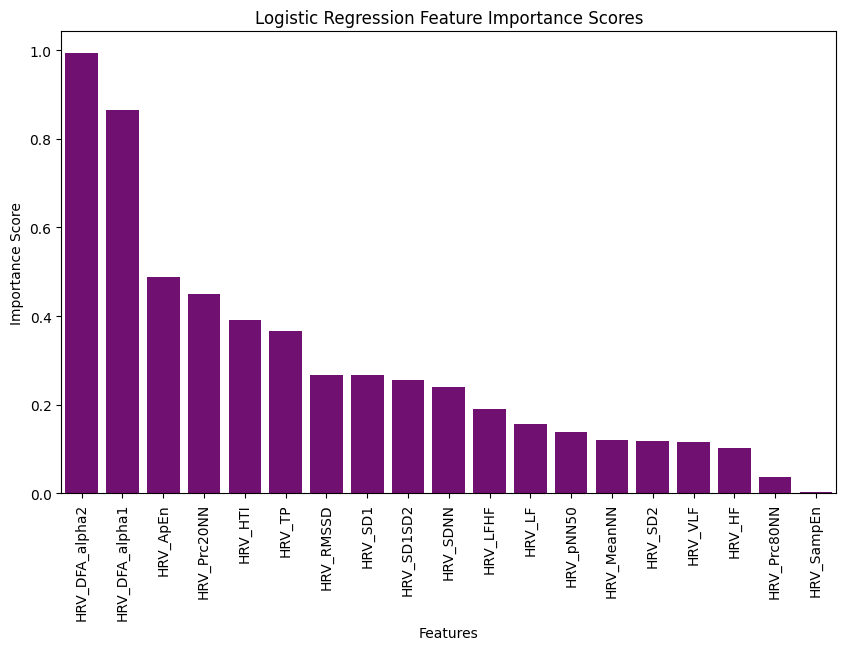

In [16]:
lr_model = LogisticRegression()
lr_model.fit(X, y)
lr_feature_importances = pd.Series(np.abs(lr_model.coef_[0]), index=X.columns)

print("Logistic Regression Feature Importance Scores:")
print(lr_feature_importances.sort_values(ascending=False))

plt.figure(figsize=(10, 6))
sns.barplot(x=lr_feature_importances.index, y=lr_feature_importances.values, order=lr_feature_importances.sort_values(ascending=False).index, color='purple')
plt.xticks(rotation=90)
plt.title('Logistic Regression Feature Importance Scores')
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.show()

Decision Tree Feature Importance Scores:
HRV_ApEn          0.126567
HRV_SDNN          0.107613
HRV_DFA_alpha2    0.104560
HRV_Prc20NN       0.092905
HRV_DFA_alpha1    0.080787
HRV_Prc80NN       0.079573
HRV_SD2           0.074206
HRV_VLF           0.044992
HRV_LF            0.044970
HRV_HTI           0.043787
HRV_SD1SD2        0.040668
HRV_HF            0.039207
HRV_LFHF          0.026995
HRV_SD1           0.023862
HRV_pNN50         0.021222
HRV_SampEn        0.015952
HRV_MeanNN        0.012855
HRV_TP            0.009641
HRV_RMSSD         0.009641
dtype: float64


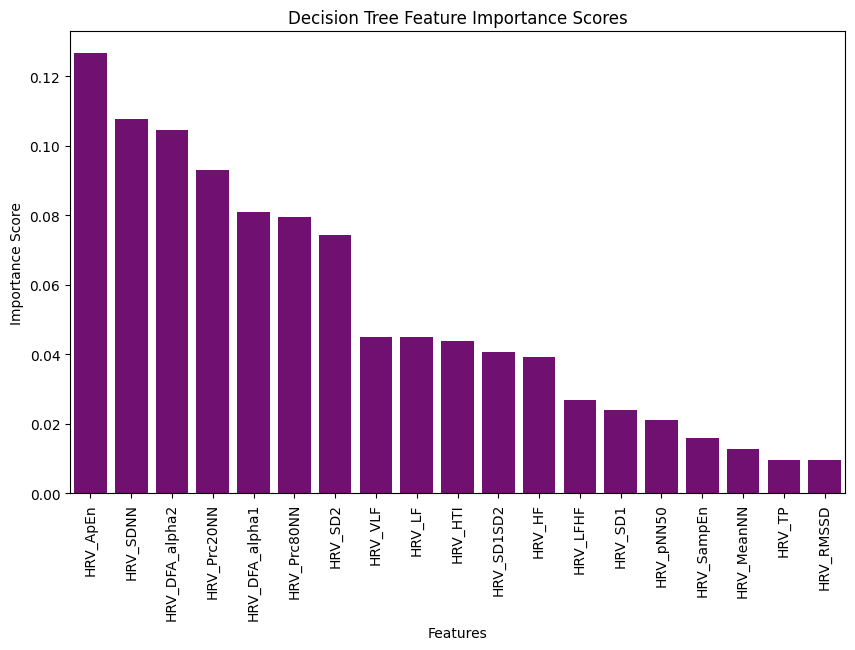

In [17]:
dt_model = DecisionTreeClassifier()
dt_model.fit(X, y)
dt_feature_importances = pd.Series(dt_model.feature_importances_, index=X.columns)

print("Decision Tree Feature Importance Scores:")
print(dt_feature_importances.sort_values(ascending=False))

plt.figure(figsize=(10, 6))
sns.barplot(x=dt_feature_importances.index, y=dt_feature_importances.values, order=dt_feature_importances.sort_values(ascending=False).index, color='purple')
plt.xticks(rotation=90)
plt.title('Decision Tree Feature Importance Scores')
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.show()

Random Forest Feature Importance Scores:
HRV_DFA_alpha2    0.080601
HRV_ApEn          0.071034
HRV_HTI           0.064264
HRV_SD2           0.060614
HRV_Prc80NN       0.057219
HRV_Prc20NN       0.056385
HRV_SDNN          0.052976
HRV_LFHF          0.051435
HRV_MeanNN        0.050962
HRV_SampEn        0.049563
HRV_LF            0.048595
HRV_SD1SD2        0.047608
HRV_DFA_alpha1    0.047586
HRV_RMSSD         0.045915
HRV_VLF           0.045535
HRV_HF            0.043665
HRV_pNN50         0.042435
HRV_SD1           0.042421
HRV_TP            0.041187
dtype: float64


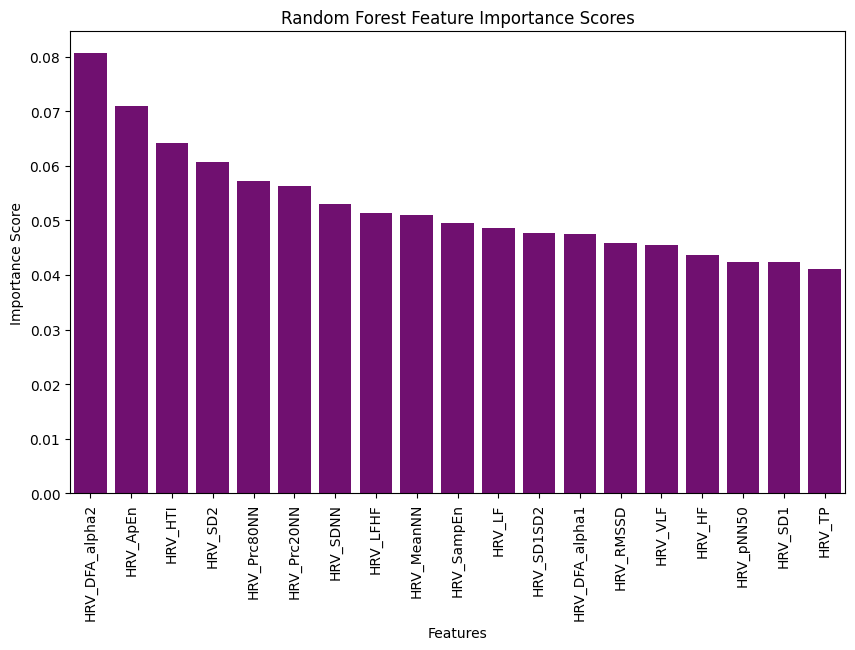

In [18]:
rf_model = RandomForestClassifier()
rf_model.fit(X, y)
rf_feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns)

print("Random Forest Feature Importance Scores:")
print(rf_feature_importances.sort_values(ascending=False))

plt.figure(figsize=(10, 6))
sns.barplot(x=rf_feature_importances.index, y=rf_feature_importances.values, order=rf_feature_importances.sort_values(ascending=False).index, color='purple')
plt.xticks(rotation=90)
plt.title('Random Forest Feature Importance Scores')
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.show()

In [19]:
anova_important_features = list(anova_feature_importances.sort_values(ascending=False).head(10).index)
lr_important_features = list(lr_feature_importances.sort_values(ascending=False).head(10).index)
dt_important_features = list(dt_feature_importances.sort_values(ascending=False).head(10).index)
rf_important_features = list(rf_feature_importances.sort_values(ascending=False).head(10).index)

selected_features = set(anova_important_features) & set(lr_important_features) & set(dt_important_features) & set(rf_important_features)

X_features = X[list(selected_features)]
X_features.head()

,HRV_HTI,HRV_Prc20NN,HRV_DFA_alpha2,HRV_SDNN
0,0.960514,0.545199,0.738601,0.890444
1,0.692573,0.425761,0.592273,0.750240
2,0.492690,0.820141,0.286937,0.445403
3,0.410530,0.676347,0.670679,0.544394
4,0.260649,0.591101,0.519608,0.284234


Tested kMeans with k = 2	Inertia: 18.7598
Tested kMeans with k = 3	Inertia: 15.3909
Tested kMeans with k = 4	Inertia: 12.8987
Tested kMeans with k = 5	Inertia: 10.9921
Tested kMeans with k = 6	Inertia: 10.3525
Tested kMeans with k = 7	Inertia: 9.1862
Tested kMeans with k = 8	Inertia: 8.7407
Tested kMeans with k = 9	Inertia: 7.4943
Tested kMeans with k = 10	Inertia: 7.4062
Tested kMeans with k = 11	Inertia: 6.9536
Tested kMeans with k = 12	Inertia: 6.8537
Tested kMeans with k = 13	Inertia: 6.4276
Tested kMeans with k = 14	Inertia: 6.0855


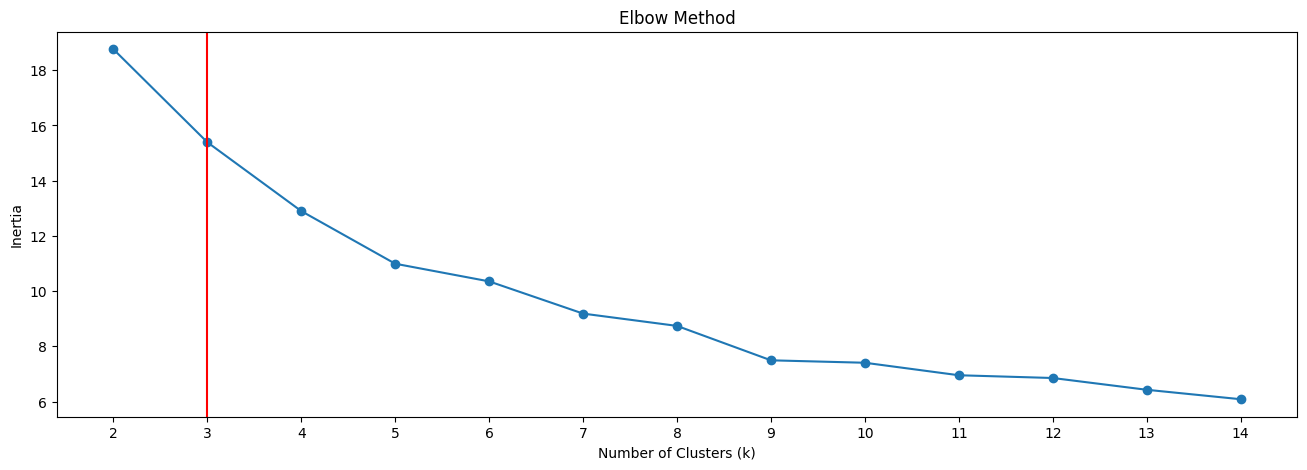

In [20]:
inertia = []
for k in range(2,15,1):
    kmeans = KMeans(n_clusters = k,random_state = 1234)
    kmeans.fit(X_features)
    inertia.append(kmeans.inertia_)
    print("Tested kMeans with k = %d\tInertia: %5.4f" % (k, kmeans.inertia_))

plt.figure(figsize = (16,5))
plt.plot(inertia, marker='o')
plt.xticks(range(0,13,1),range(2,15,1))
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.axvline(1, color = "r")
plt.show()

(166, 3) 

 5 observations of the new df:
 [[ 0.6186697   0.25168557 -0.361902  ]
 [ 0.34910326  0.06567726 -0.25707715]
 [ 0.24226815  0.00709505  0.34166135]
 [ 0.10867775  0.26302752  0.04810965]
 [-0.14680939  0.08206093  0.17673397]]


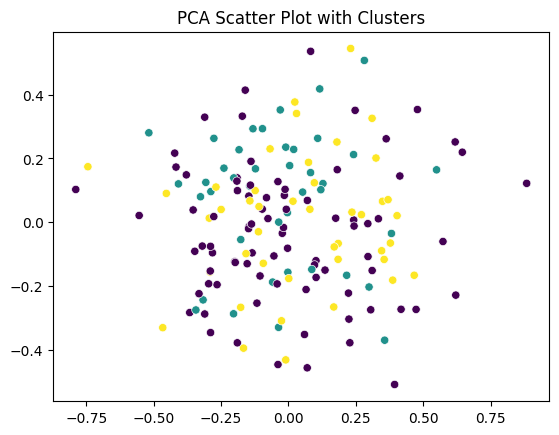

In [21]:
pca = PCA(n_components=3)
x_pca_fit = pca.fit_transform(X_features)

print(x_pca_fit.shape,'\n\n 5 observations of the new df:\n',x_pca_fit[0:5])

sns.scatterplot(x=x_pca_fit[:,0], y=x_pca_fit[:,1], c=y)
plt.title('PCA Scatter Plot with Clusters')
plt.show()

In [22]:
def print_model_evaluation(model, X_train, y_train, X_test, y_test, model_name):
    # Train and predict
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred) * 100

    # Classification report and confusion matrix
    class_report = classification_report(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)

    %matplotlib inline
    # Print results
    print(f"Model: {model_name}")
    print(f"Accuracy: {accuracy:.2f}%")
    print("\nClassification Report:")
    print(class_report)

    # Plot confusion matrix
    plt.figure(figsize=(4,2))
    sns.heatmap(pd.DataFrame(conf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
    plt.tight_layout()
    plt.title('Confusion matrix', y=1)
    plt.ylabel('Actual label')
    plt.xlabel('Predicted label')
    plt.show()

In [23]:
X_train, X_test, y_train, y_test = train_test_split(x_pca_fit, y, test_size=0.3, random_state=42)

(X_train.shape,X_test.shape,y_train.shape,y_test.shape)

((116, 3), (50, 3), (116,), (50,))

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Model: Logistic Regression
Accuracy: 62.00%

Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.97      0.75        29
           1       0.00      0.00      0.00         9
           2       0.75      0.25      0.38        12

    accuracy                           0.62        50
   macro avg       0.45      0.41      0.37        50
weighted avg       0.53      0.62      0.52        50



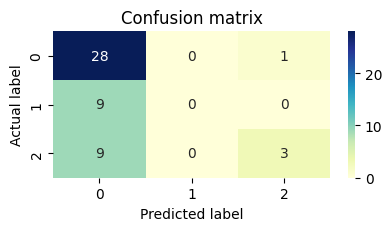

In [24]:
lr_model = LogisticRegression()
print_model_evaluation(lr_model, X_train, y_train, X_test, y_test, "Logistic Regression")

Model: K Nearest Neighbors
Accuracy: 56.00%

Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.76      0.69        29
           1       0.33      0.33      0.33         9
           2       0.50      0.25      0.33        12

    accuracy                           0.56        50
   macro avg       0.49      0.45      0.45        50
weighted avg       0.54      0.56      0.54        50



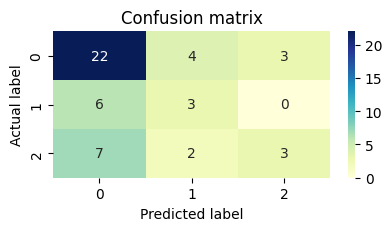

In [25]:
knn_model = KNeighborsClassifier()
print_model_evaluation(knn_model, X_train, y_train, X_test, y_test, "K Nearest Neighbors")

Model: Support Vector Machine
Accuracy: 62.00%

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.83      0.75        29
           1       0.38      0.33      0.35         9
           2       0.57      0.33      0.42        12

    accuracy                           0.62        50
   macro avg       0.54      0.50      0.51        50
weighted avg       0.60      0.62      0.60        50



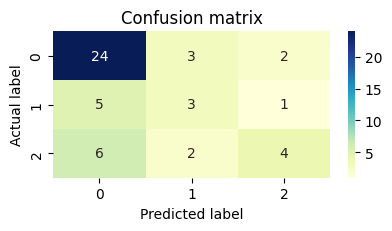

In [26]:
svm_model = SVC()
print_model_evaluation(svm_model, X_train, y_train, X_test, y_test, "Support Vector Machine")

Model: Decision Tree
Accuracy: 40.00%

Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.38      0.46        29
           1       0.14      0.33      0.20         9
           2       0.60      0.50      0.55        12

    accuracy                           0.40        50
   macro avg       0.44      0.40      0.40        50
weighted avg       0.51      0.40      0.43        50



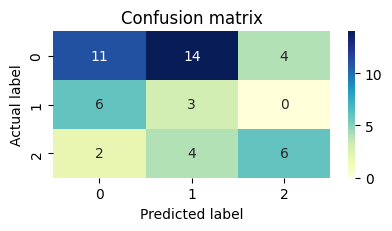

In [27]:
dt_model = DecisionTreeClassifier()
print_model_evaluation(dt_model, X_train, y_train, X_test, y_test, "Decision Tree")

Model: Random Forest
Accuracy: 44.00%

Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.48      0.52        29
           1       0.21      0.33      0.26         9
           2       0.45      0.42      0.43        12

    accuracy                           0.44        50
   macro avg       0.41      0.41      0.40        50
weighted avg       0.47      0.44      0.45        50



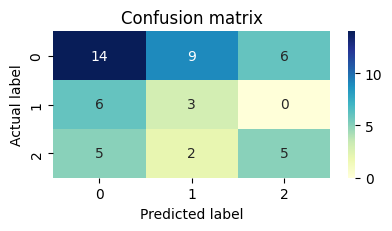

In [28]:
rf_model = RandomForestClassifier()
print_model_evaluation(rf_model, X_train, y_train, X_test, y_test, "Random Forest")

Model: Naive Bayes
Accuracy: 66.00%

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.79      0.77        29
           1       0.33      0.33      0.33         9
           2       0.70      0.58      0.64        12

    accuracy                           0.66        50
   macro avg       0.59      0.57      0.58        50
weighted avg       0.66      0.66      0.66        50



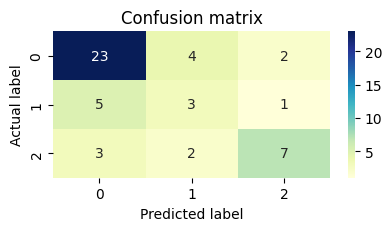

In [29]:
nb_model = GaussianNB()
print_model_evaluation(nb_model, X_train, y_train, X_test, y_test, "Naive Bayes")

In [30]:
# Function to perform cross-validation and return average accuracy
def perform_cross_validation(model, X, y, cv=5):
    cv_scores = cross_val_score(model, X, y, cv=cv)
    return cv_scores.mean()

In [31]:
# Cross-validation for each model
lr_cv_accuracy = perform_cross_validation(lr_model, X_features, y)
svm_cv_accuracy = perform_cross_validation(svm_model, X_features, y)
knn_cv_accuracy = perform_cross_validation(knn_model, X_features, y)
nb_cv_accuracy = perform_cross_validation(nb_model, X_features, y)
dt_cv_accuracy = perform_cross_validation(dt_model, X_features, y)
rf_cv_accuracy = perform_cross_validation(rf_model, X_features, y)

In [32]:
cv_results = {
    "Logistic Regression": lr_cv_accuracy,
    "K-Nearest Neighbors": knn_cv_accuracy,
    "Support Vector Machine": svm_cv_accuracy,
    "Decision Tree": dt_cv_accuracy,
    "Random Forest": rf_cv_accuracy,
    "Naive Bayes": nb_cv_accuracy
}

# Convert to percentage format and print
formatted_results = {model: f"{accuracy * 100:.2f}%" for model, accuracy in cv_results.items()}
formatted_results

{'Logistic Regression': '51.80%',
 'K-Nearest Neighbors': '48.16%',
 'Support Vector Machine': '52.99%',
 'Decision Tree': '37.38%',
 'Random Forest': '48.20%',
 'Naive Bayes': '53.03%'}

In [33]:
param_grid = {
    'penalty': ['l1', 'l2'],
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'saga']
}

grid_search = GridSearchCV(estimator=lr_model, param_grid=param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which 

GridSearchCV(cv=5, estimator=LogisticRegression(),
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100],
                         'penalty': ['l1', 'l2'],
                         'solver': ['liblinear', 'saga']},
             scoring='accuracy')

In [34]:
grid_search.best_params_

{'C': 100, 'penalty': 'l1', 'solver': 'saga'}

In [35]:
best_lr_model = grid_search.best_estimator_

y_pred = best_lr_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", accuracy)

Test Accuracy: 0.66


              precision    recall  f1-score   support

           0       0.68      0.90      0.78        29
           1       0.67      0.22      0.33         9
           2       0.56      0.42      0.48        12

    accuracy                           0.66        50
   macro avg       0.64      0.51      0.53        50
weighted avg       0.65      0.66      0.62        50



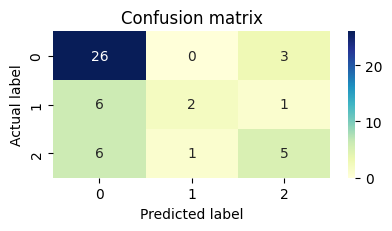

In [36]:
conf_matrix = confusion_matrix(y_test, y_pred)

print(classification_report(y_test, y_pred))

plt.figure(figsize=(4,2))
sns.heatmap(pd.DataFrame(conf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
plt.tight_layout()
plt.title('Confusion matrix', y=1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.show()

In [37]:
param_grid = {'C': [0.1,1, 10, 100], 'kernel': ['rbf'], 'gamma': [1,0.1,0.01,0.001,0.0001]}
grid_search = GridSearchCV(svm_model, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100],
                         'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
                         'kernel': ['rbf']},
             scoring='accuracy')

In [38]:
grid_search.best_params_

{'C': 100, 'gamma': 0.1, 'kernel': 'rbf'}

In [39]:
best_svc_model = grid_search.best_estimator_

y_pred = best_svc_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", accuracy)

Test Accuracy: 0.6


              precision    recall  f1-score   support

           0       0.61      0.93      0.74        29
           1       0.00      0.00      0.00         9
           2       0.50      0.25      0.33        12

    accuracy                           0.60        50
   macro avg       0.37      0.39      0.36        50
weighted avg       0.48      0.60      0.51        50



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


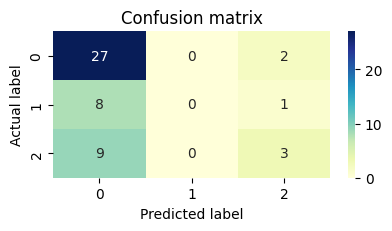

In [40]:
conf_matrix = confusion_matrix(y_test, y_pred)

print(classification_report(y_test, y_pred))

plt.figure(figsize=(4,2))
sns.heatmap(pd.DataFrame(conf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
plt.tight_layout()
plt.title('Confusion matrix', y=1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.show()

In [41]:
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}
knn_model = KNeighborsClassifier()
grid_search = GridSearchCV(estimator=knn_model, param_grid=param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'metric': ['euclidean', 'manhattan'],
                         'n_neighbors': [3, 5, 7, 9, 11],
                         'weights': ['uniform', 'distance']},
             scoring='accuracy')

In [42]:
grid_search.best_params_

{'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'uniform'}

In [43]:
best_knn_model = grid_search.best_estimator_

y_pred = best_knn_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", accuracy)

Test Accuracy: 0.56


              precision    recall  f1-score   support

           0       0.63      0.76      0.69        29
           1       0.33      0.33      0.33         9
           2       0.50      0.25      0.33        12

    accuracy                           0.56        50
   macro avg       0.49      0.45      0.45        50
weighted avg       0.54      0.56      0.54        50



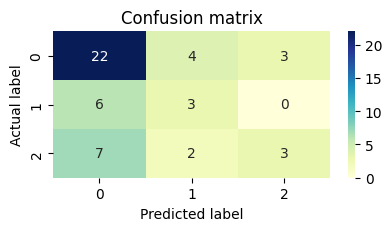

In [44]:
conf_matrix = confusion_matrix(y_test, y_pred)

print(classification_report(y_test, y_pred))

plt.figure(figsize=(4,2))
sns.heatmap(pd.DataFrame(conf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
plt.tight_layout()
plt.title('Confusion matrix', y=1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.show()

In [45]:
param_grid = {
    'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]
}

nb_model = GaussianNB()
grid_search = GridSearchCV(estimator=nb_model, param_grid=param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=GaussianNB(),
             param_grid={'var_smoothing': [1e-09, 1e-08, 1e-07, 1e-06, 1e-05]},
             scoring='accuracy')

In [46]:
grid_search.best_params_

{'var_smoothing': 1e-09}

In [47]:
best_nb_model = grid_search.best_estimator_

y_pred = best_nb_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", accuracy)

Test Accuracy: 0.66


              precision    recall  f1-score   support

           0       0.74      0.79      0.77        29
           1       0.33      0.33      0.33         9
           2       0.70      0.58      0.64        12

    accuracy                           0.66        50
   macro avg       0.59      0.57      0.58        50
weighted avg       0.66      0.66      0.66        50



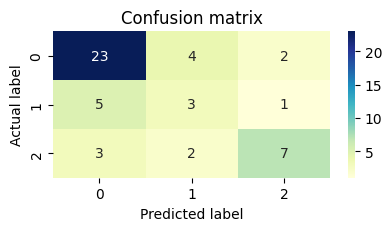

In [48]:
conf_matrix = confusion_matrix(y_test, y_pred)

print(classification_report(y_test, y_pred))

plt.figure(figsize=(4,2))
sns.heatmap(pd.DataFrame(conf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
plt.tight_layout()
plt.title('Confusion matrix', y=1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.show()

In [49]:
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

dt_model = DecisionTreeClassifier()
grid_search = GridSearchCV(estimator=dt_model, param_grid=param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 5, 10, 15],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='accuracy')

In [50]:
grid_search.best_params_

{'criterion': 'entropy',
 'max_depth': None,
 'min_samples_leaf': 2,
 'min_samples_split': 2}

In [51]:
best_dt_model = grid_search.best_estimator_
y_pred = best_dt_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", accuracy)

Test Accuracy: 0.34


              precision    recall  f1-score   support

           0       0.48      0.45      0.46        29
           1       0.11      0.22      0.15         9
           2       0.40      0.17      0.24        12

    accuracy                           0.34        50
   macro avg       0.33      0.28      0.28        50
weighted avg       0.40      0.34      0.35        50



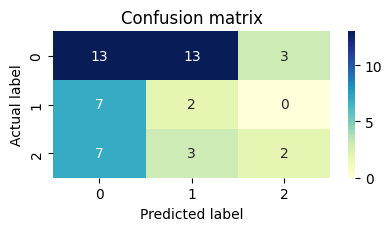

In [52]:
conf_matrix = confusion_matrix(y_test, y_pred)

print(classification_report(y_test, y_pred))

plt.figure(figsize=(4,2))
sns.heatmap(pd.DataFrame(conf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
plt.tight_layout()
plt.title('Confusion matrix', y=1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.show()

In [53]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
rf_model = RandomForestClassifier()
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 5, 10, 15],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             scoring='accuracy')

In [54]:
grid_search.best_params_

{'criterion': 'gini',
 'max_depth': 10,
 'min_samples_leaf': 4,
 'min_samples_split': 2,
 'n_estimators': 50}

In [55]:
best_rf_model = grid_search.best_estimator_

y_pred = best_rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", accuracy)

Test Accuracy: 0.62


              precision    recall  f1-score   support

           0       0.72      0.72      0.72        29
           1       0.36      0.44      0.40         9
           2       0.60      0.50      0.55        12

    accuracy                           0.62        50
   macro avg       0.56      0.56      0.56        50
weighted avg       0.63      0.62      0.62        50



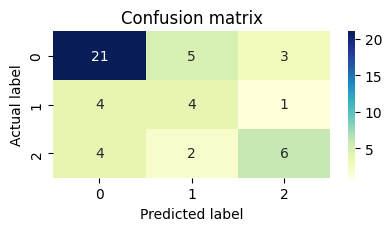

In [56]:
conf_matrix = confusion_matrix(y_test, y_pred)

print(classification_report(y_test, y_pred))

plt.figure(figsize=(4,2))
sns.heatmap(pd.DataFrame(conf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
plt.tight_layout()
plt.title('Confusion matrix', y=1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.show()